# News vendor problem

## Imports

In [1]:
from news_vendor.items import Item
from news_vendor.demand_distribution import NormalDemand, SampledDemand
from news_vendor.solvers import SingleItemNewsvendorSolver, MultiItemConstrainedSolver
from news_vendor.plotting import NewsvendorVisualizer 
import numpy as np

## Single Item problem

### Normal Distribution

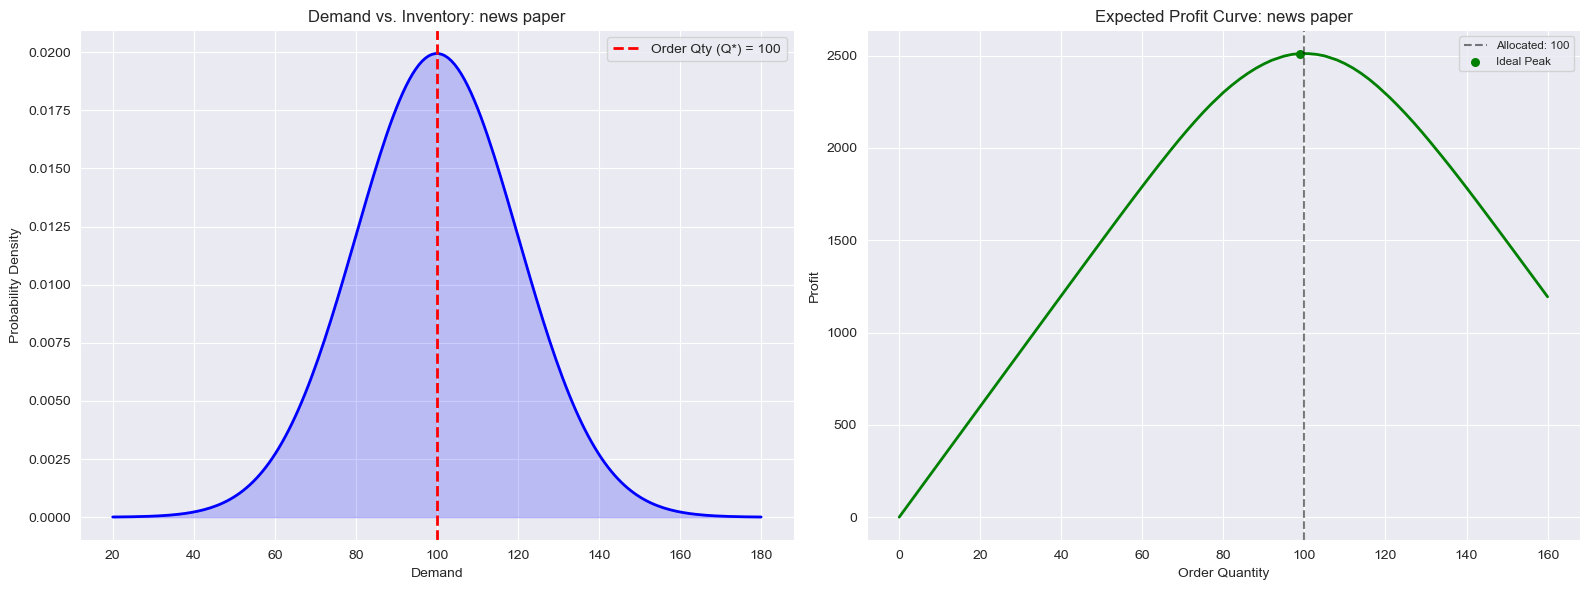

In [2]:
newspaper = Item(name="news paper", cost_price=30, selling_price=60, salvage_value=0)
demand = NormalDemand(mean=100, std_dev=20)
solver = SingleItemNewsvendorSolver(item=newspaper, demand_distribution=demand)

# solve
optimal_quantity = solver.solve()

# show results
results = NewsvendorVisualizer().plot_single_item_analysis(solver)


### Sampled Distribution

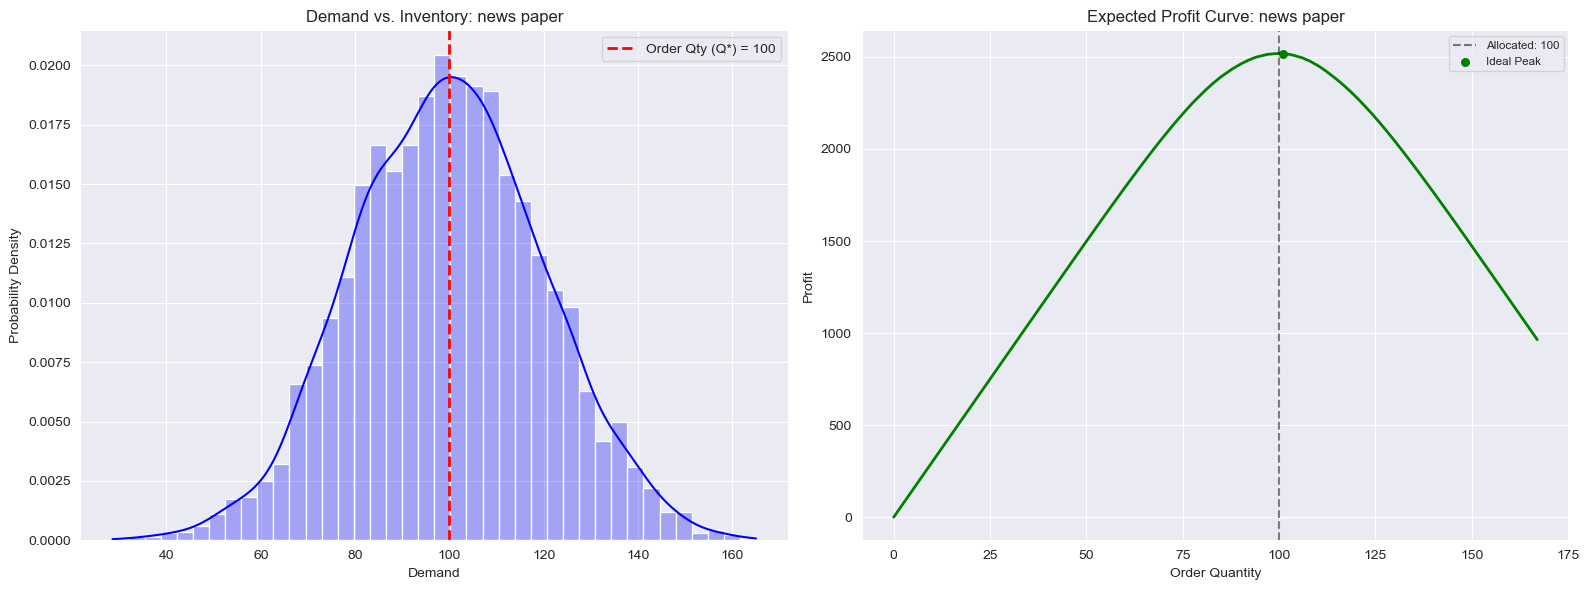

In [3]:
raw_trace_data = np.random.normal(loc=100, scale=20, size=(4, 1000))
    
# The class will handle the flattening of the (4, 1000) array automatically
demand = SampledDemand(samples=raw_trace_data)
solver = SingleItemNewsvendorSolver(item=newspaper, demand_distribution=demand)

# solve
optimal_quantity = solver.solve()

# show results
results = NewsvendorVisualizer().plot_single_item_analysis(solver)


## Multiple Items (with constraint)

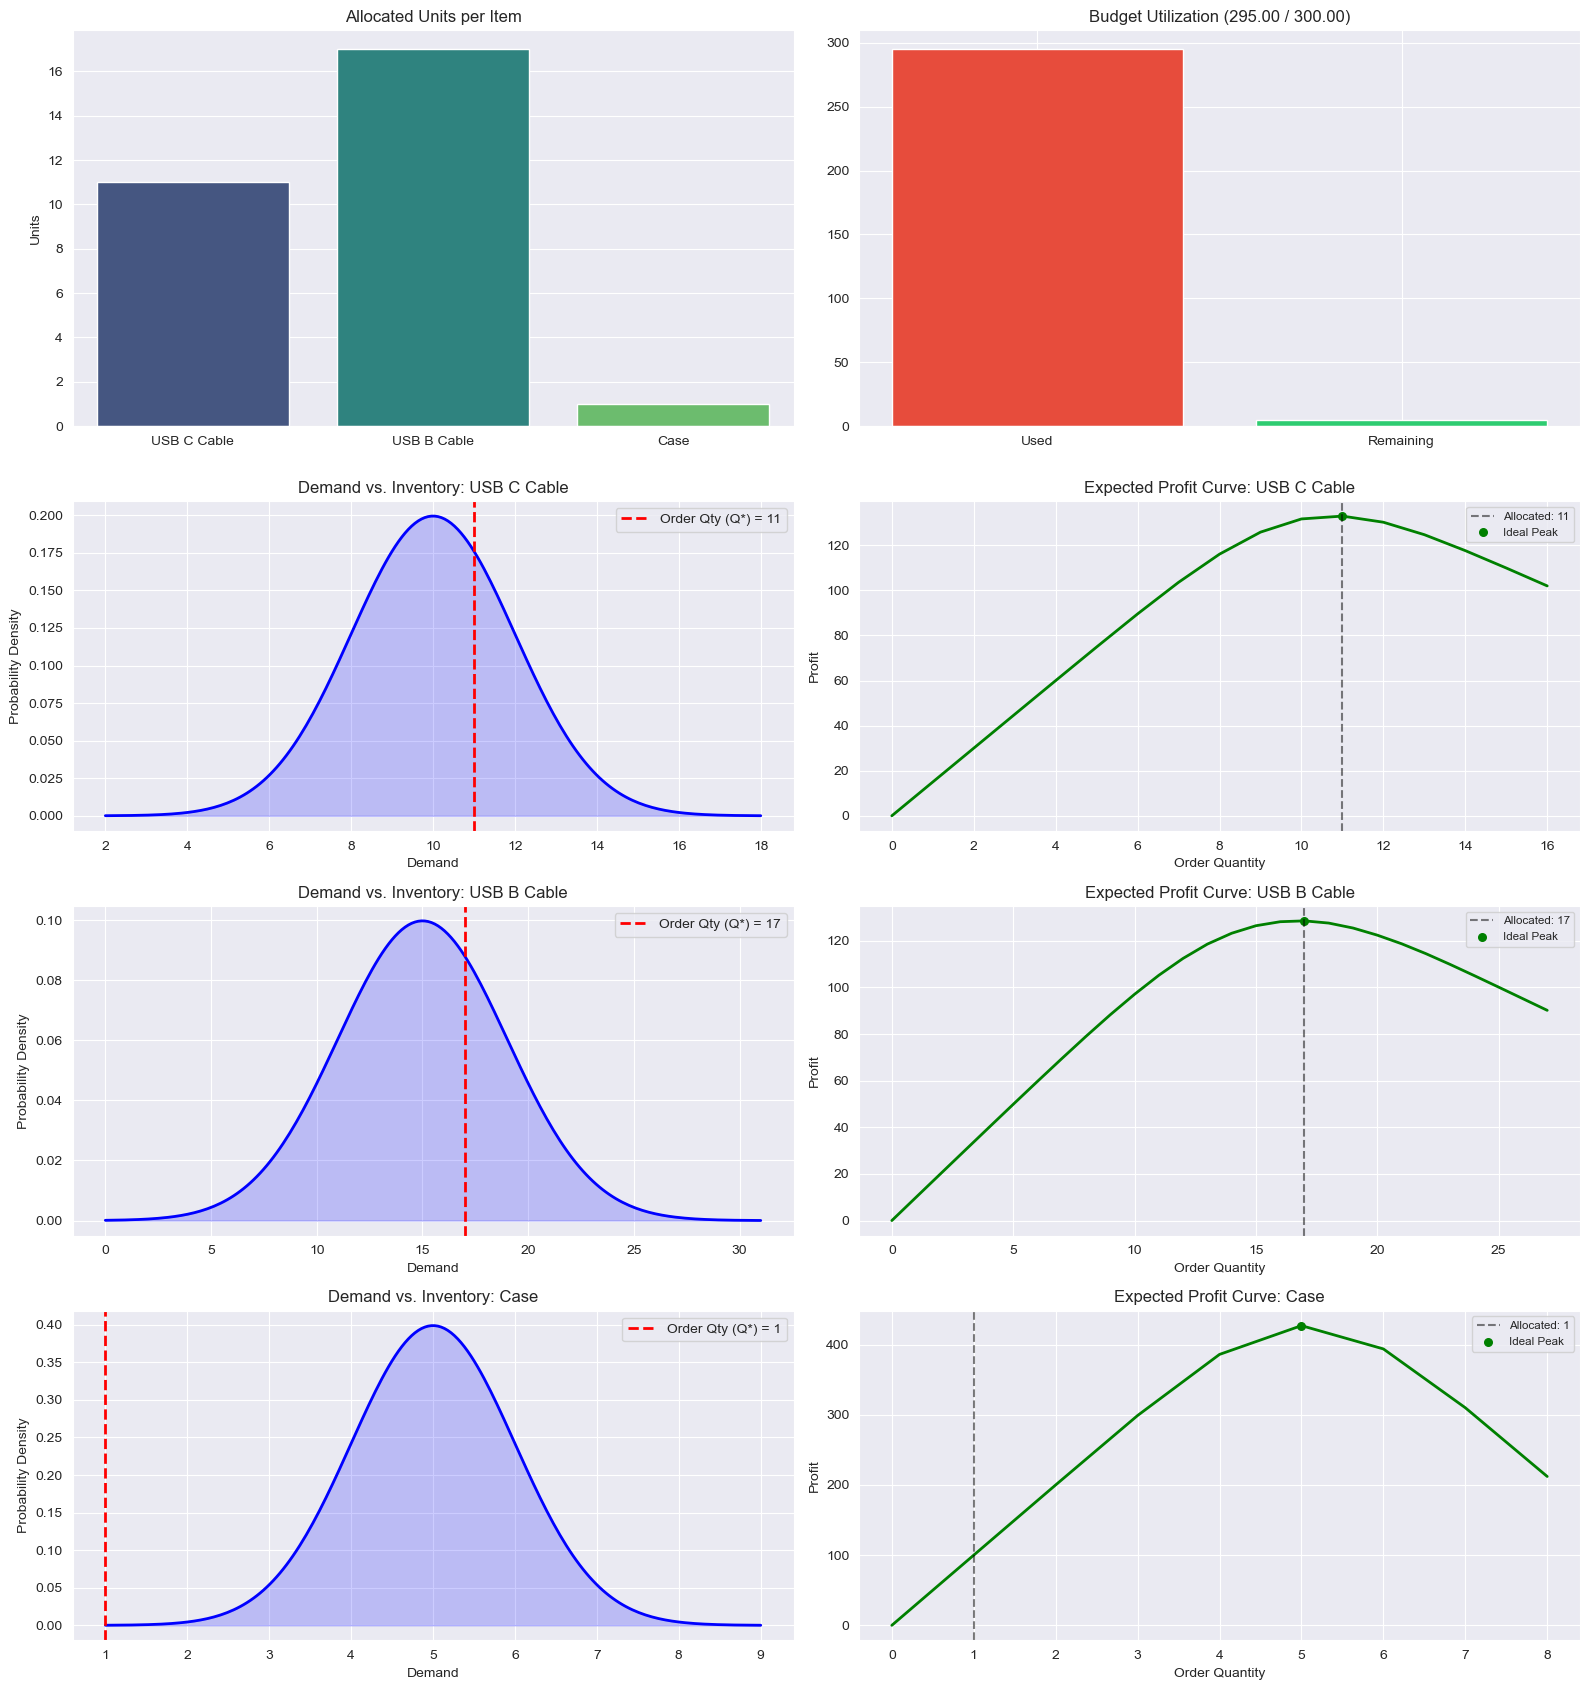

In [8]:
usb_C = Item("USB C Cable", 10, 25, 2)
usb_C_dem = NormalDemand(10, 2)

usb_B = Item("USB B Cable", 5, 15, 0)
usb_B_dem = NormalDemand(15, 4)

Case = Item("Case", 100, 200, 0)
Case_dem = NormalDemand(5, 1)

problems = [(usb_C, usb_C_dem), (usb_B, usb_B_dem), (Case, Case_dem)]

solver = MultiItemConstrainedSolver(problems, budget=300)
allocation = solver.solve()
    
# show results
results = NewsvendorVisualizer().plot_multi_item_allocation(solver)
